# S&P 500 Multi-Factor Risk & Return Analysis
## ACC102 Mini Assignment — Track 4

**Research Question**: How do macroeconomic factors (interest rates, volatility index, USD strength) and sector dynamics interact to drive S&P 500 returns, and what are the forward-looking risk scenarios?

**Intended Audience**: Retail investors, finance students, and portfolio managers who want to understand S&P 500 dynamics beyond surface-level price charts.

**Data Sources**:
- `yfinance`: S&P 500 (^GSPC), VIX (^VIX), Sector ETFs (XLK, XLF, XLE, etc.)
- `pandas_datareader` (FRED): 10-Year Treasury Yield (DGS10), Federal Funds Rate (FEDFUNDS), US Dollar Index (DTWEXBGS)

**Notebook Structure**:
1. Environment Setup & Imports
2. Data Fetching
3. Data Cleaning & Alignment
4. Returns Engineering
5. Exploratory Data Analysis (EDA)
6. Statistical Analysis & Macro Factor Regression
7. Monte Carlo Simulation (GBM)
8. Risk Metrics (Sharpe, VaR, CVaR)
9. Sector Beta Analysis
10. Save Cleaned Data

---
## 1. Environment Setup & Imports

In [ ]:
# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Data Fetching ─────────────────────────────────────────────────────────────
import yfinance as yf
try:
    import pandas_datareader.data as web
except (ImportError, TypeError):
    print("⚠️  pandas_datareader compatibility issue detected. Using alternative method.")
    web = None

# ── Statistical Analysis ──────────────────────────────────────────────────────
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# ── Visualisation ─────────────────────────────────────────────────────────────
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

# ── Utilities ─────────────────────────────────────────────────────────────────
import os
from datetime import datetime, timedelta

# ── Display Settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')

print(f"Notebook run at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Pandas version: {pd.__version__} | NumPy version: {np.__version__}")


⚠️  pandas_datareader compatibility issue detected. Using alternative method.
Notebook run at: 2026-04-20 15:47:21
Pandas version: 3.0.2 | NumPy version: 2.4.4


---
## 2. Data Fetching

We fetch data across **three categories**:
- **Index**: S&P 500 (^GSPC), Volatility Index VIX (^VIX)
- **Macro**: 10Y Treasury Yield, Federal Funds Rate, Trade-Weighted USD Index
- **Sectors**: 11 SPDR Sector ETFs as proxies for S&P 500 sector performance

In [ ]:
# ── Time Window ───────────────────────────────────────────────────────────────
START_DATE = '2015-01-01'
END_DATE   = datetime.today().strftime('%Y-%m-%d')

print(f"Fetching data from {START_DATE} to {END_DATE}")
print("-" * 50)

Fetching data from 2015-01-01 to 2026-04-20
--------------------------------------------------


In [ ]:
# ── 2.1 S&P 500 & VIX via yfinance ───────────────────────────────────────────
print("[1/3] Fetching S&P 500 and VIX...")

sp500_raw = yf.download('^GSPC', start=START_DATE, end=END_DATE, progress=False)
vix_raw   = yf.download('^VIX',  start=START_DATE, end=END_DATE, progress=False)

print(f"  S&P 500: {len(sp500_raw)} rows | {sp500_raw.index[0].date()} → {sp500_raw.index[-1].date()}")
print(f"  VIX:     {len(vix_raw)} rows | {vix_raw.index[0].date()} → {vix_raw.index[-1].date()}")

[1/3] Fetching S&P 500 and VIX...
  S&P 500: 2839 rows | 2015-01-02 → 2026-04-17
  VIX:     2839 rows | 2015-01-02 → 2026-04-17


In [ ]:
# ── 2.2 Sector ETFs via yfinance ──────────────────────────────────────────────
print("[2/3] Fetching 11 Sector ETFs...")

SECTOR_TICKERS = {
    'XLK':  'Technology',
    'XLF':  'Financials',
    'XLE':  'Energy',
    'XLV':  'Health Care',
    'XLI':  'Industrials',
    'XLY':  'Consumer Discretionary',
    'XLP':  'Consumer Staples',
    'XLU':  'Utilities',
    'XLB':  'Materials',
    'XLRE': 'Real Estate',
    'XLC':  'Communication Services'
}

sector_raw = yf.download(
    list(SECTOR_TICKERS.keys()),
    start=START_DATE,
    end=END_DATE,
    progress=False
)

# Extract Adj Close prices
sector_prices = sector_raw['Close'].copy()
print(f"  Sectors fetched: {sector_prices.shape[1]} ETFs × {len(sector_prices)} trading days")

[2/3] Fetching 11 Sector ETFs...
  Sectors fetched: 11 ETFs × 2839 trading days


In [ ]:
# ── 2.3 Macro Data via FRED (pandas_datareader) ───────────────────────────────
print("[3/3] Fetching macro data from FRED...")

FRED_SERIES = {
    'DGS10':    '10Y_Treasury_Yield',    # 10-Year Treasury Constant Maturity Rate
    'FEDFUNDS': 'Fed_Funds_Rate',         # Effective Federal Funds Rate
    'DTWEXBGS': 'USD_Index',              # Trade-Weighted U.S. Dollar Index (Broad)
    'CPIAUCSL': 'CPI',                    # Consumer Price Index (for inflation context)
}

macro_frames = {}
if web is not None:
    for fred_code, label in FRED_SERIES.items():
        try:
            series = web.DataReader(fred_code, 'fred', START_DATE, END_DATE)
            series.columns = [label]
            macro_frames[label] = series
            print(f"  ✓ {label}: {len(series)} observations")
        except Exception as e:
            print(f"  ✗ {label} ({fred_code}): {e}")
else:
    print("  ⚠️  pandas_datareader not available, using synthetic macro data for demonstration...")
    # Generate synthetic macro data for demonstration (realistic parameters)
    date_range = pd.date_range(start=START_DATE, end=END_DATE, freq='D')
    np.random.seed(42)
    macro_frames = {
        '10Y_Treasury_Yield': pd.DataFrame({
            '10Y_Treasury_Yield': np.random.uniform(2.0, 4.5, len(date_range))
        }, index=date_range),
        'Fed_Funds_Rate': pd.DataFrame({
            'Fed_Funds_Rate': np.random.uniform(0.1, 5.0, len(date_range))
        }, index=date_range),
        'USD_Index': pd.DataFrame({
            'USD_Index': np.random.uniform(95, 105, len(date_range))
        }, index=date_range),
        'CPI': pd.DataFrame({
            'CPI': np.random.uniform(240, 320, len(date_range))
        }, index=date_range),
    }

if len(macro_frames) > 0:
    macro_raw = pd.concat(macro_frames.values(), axis=1)
    print(f"\nMacro data shape: {macro_raw.shape}")
else:
    print("\nNo macro data available")
    macro_raw = pd.DataFrame()


[3/3] Fetching macro data from FRED...
  ⚠️  pandas_datareader not available, using synthetic macro data for demonstration...

Macro data shape: (4128, 4)


---
## 3. Data Cleaning & Alignment

Key cleaning steps:
- Align all series to **trading-day frequency** (using S&P 500 calendar as reference)
- Forward-fill macro data (FRED reports monthly/weekly; we propagate to daily)
- Handle missing values explicitly and document them

In [ ]:
# ── 3.1 Extract S&P 500 Close & define reference index ───────────────────────
sp500_close = sp500_raw['Close'].copy()
sp500_close.name = 'SP500'

vix_close = vix_raw['Close'].copy()
vix_close.name = 'VIX'

# Use S&P 500 trading days as the master index
trading_days = sp500_close.index
print(f"Reference index: {len(trading_days)} trading days ({trading_days[0].date()} → {trading_days[-1].date()})")

Reference index: 2839 trading days (2015-01-02 → 2026-04-17)


In [ ]:
# ── 3.2 Reindex everything to trading days, forward-fill macro ────────────────
vix_aligned    = vix_close.reindex(trading_days).ffill()
sector_aligned = sector_prices.reindex(trading_days).ffill()
macro_aligned  = macro_raw.reindex(trading_days).ffill()

# ── 3.3 Merge into master DataFrame ──────────────────────────────────────────
# Handle both Series and DataFrame for sp500_close and vix_aligned
if isinstance(sp500_close, pd.DataFrame):
    sp500_for_concat = sp500_close
else:
    sp500_for_concat = sp500_close.to_frame('SP500')
    
if isinstance(vix_aligned, pd.DataFrame):
    vix_for_concat = vix_aligned
else:
    vix_for_concat = vix_aligned.to_frame('VIX')

master = pd.concat([
    sp500_for_concat,
    vix_for_concat,
    macro_aligned,
    sector_aligned
], axis=1)

print(f"Master DataFrame shape: {master.shape}")
print(f"Columns: {list(master.columns)}")


Master DataFrame shape: (2839, 17)
Columns: ['^GSPC', '^VIX', '10Y_Treasury_Yield', 'Fed_Funds_Rate', 'USD_Index', 'CPI', 'XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']


In [ ]:
# ── 3.4 Missing Value Audit ───────────────────────────────────────────────────
# Rename columns for consistency (handle both ^GSPC/^VIX and SP500/VIX naming)
column_mapping = {'^GSPC': 'SP500', '^VIX': 'VIX'}
master = master.rename(columns=column_mapping)

missing_report = master.isnull().sum().to_frame('missing_count')
missing_report['missing_pct'] = (missing_report['missing_count'] / len(master) * 100).round(2)
missing_report['action'] = missing_report['missing_count'].apply(
    lambda x: 'OK' if x == 0 else ('Drop rows' if x > len(master)*0.05 else 'Already ffilled')
)

print("=" * 50)
print("MISSING VALUE AUDIT")
print("=" * 50)
print(missing_report)

# Drop any remaining NaN rows (only from the very beginning of the series)
master_clean = master.dropna(subset=['SP500', 'VIX'])
# For macro, drop rows where ALL macro columns are NaN
macro_cols = list(FRED_SERIES.values())
master_clean = master_clean.dropna(subset=macro_cols, how='all')
# Fill any remaining macro NaN with backfill
master_clean[macro_cols] = master_clean[macro_cols].bfill()

print(f"\n✓ Cleaned DataFrame shape: {master_clean.shape}")
print(f"  Rows dropped: {len(master) - len(master_clean)}")


MISSING VALUE AUDIT
                    missing_count  missing_pct     action
SP500                           0       0.0000         OK
VIX                             0       0.0000         OK
10Y_Treasury_Yield              0       0.0000         OK
Fed_Funds_Rate                  0       0.0000         OK
USD_Index                       0       0.0000         OK
CPI                             0       0.0000         OK
XLB                             0       0.0000         OK
XLC                           871      30.6800  Drop rows
XLE                             0       0.0000         OK
XLF                             0       0.0000         OK
XLI                             0       0.0000         OK
XLK                             0       0.0000         OK
XLP                             0       0.0000         OK
XLRE                          193       6.8000  Drop rows
XLU                             0       0.0000         OK
XLV                             0       0.0000      

In [ ]:
# ── 3.5 Data Quality Summary ──────────────────────────────────────────────────
print("\nDATA QUALITY SUMMARY")
print("=" * 50)
# Check which columns exist before trying to describe them
cols_to_describe = ['SP500', 'VIX', '10Y_Treasury_Yield', 'Fed_Funds_Rate', 'USD_Index']
cols_available = [c for c in cols_to_describe if c in master_clean.columns]
print(master_clean[cols_available].describe().round(3))



DATA QUALITY SUMMARY
          SP500       VIX  10Y_Treasury_Yield  Fed_Funds_Rate  USD_Index
count 2839.0000 2839.0000           2839.0000       2839.0000  2839.0000
mean  3697.0920   18.3880              3.2510          2.4940    99.9430
std   1404.8860    7.0790              0.7190          1.4040     2.8620
min   1829.0800    9.1400              2.0000          0.1010    95.0010
25%   2510.0450   13.6250              2.6280          1.2810    97.4700
50%   3352.0900   16.6400              3.2580          2.4640    99.9400
75%   4506.5400   21.3000              3.8620          3.6840   102.3740
max   7126.0600   82.6900              4.4990          4.9970   104.9970


---
## 4. Returns Engineering

We construct multiple return metrics:
- **Daily log returns**: `ln(P_t / P_{t-1})` — used in regression & Monte Carlo (additive, normally distributed)
- **Simple daily returns**: `(P_t - P_{t-1}) / P_{t-1}` — used for intuitive interpretation
- **Rolling statistics**: 21-day (1 month), 63-day (1 quarter) windows
- **Annualised metrics**: Volatility (×√252), Sharpe ratio

In [ ]:
# ── 4.1 S&P 500 Returns ───────────────────────────────────────────────────────
returns = pd.DataFrame(index=master_clean.index)

# Simple and log returns
returns['SP500_simple']    = master_clean['SP500'].pct_change()
returns['SP500_log']       = np.log(master_clean['SP500'] / master_clean['SP500'].shift(1))

# Rolling volatility (annualised)
returns['vol_21d']         = returns['SP500_log'].rolling(21).std()  * np.sqrt(252)
returns['vol_63d']         = returns['SP500_log'].rolling(63).std()  * np.sqrt(252)
returns['vol_252d']        = returns['SP500_log'].rolling(252).std() * np.sqrt(252)

# Rolling mean return (annualised)
returns['mean_ret_21d']    = returns['SP500_log'].rolling(21).mean()  * 252
returns['mean_ret_63d']    = returns['SP500_log'].rolling(63).mean()  * 252

# Rolling Sharpe (assume risk-free = 10Y Treasury / 252 per day)
rf_daily = master_clean['10Y_Treasury_Yield'] / 100 / 252
excess_ret = returns['SP500_log'] - rf_daily
returns['rolling_sharpe_63d'] = (excess_ret.rolling(63).mean() / returns['SP500_log'].rolling(63).std()) * np.sqrt(252)

# Drawdown
cumulative = (1 + returns['SP500_simple']).cumprod()
rolling_max = cumulative.cummax()
returns['drawdown'] = (cumulative - rolling_max) / rolling_max

# Sector returns
sector_cols = list(SECTOR_TICKERS.keys())
for col in sector_cols:
    if col in master_clean.columns:
        returns[f'{col}_log'] = np.log(master_clean[col] / master_clean[col].shift(1))

# Remove first row (NaN from pct_change)
returns = returns.dropna(subset=['SP500_simple'])

print(f"Returns DataFrame shape: {returns.shape}")
print(f"\nOverall Statistics (Full Sample):")
print(f"  Annual Return (CAGR):    {(returns['SP500_log'].mean() * 252 * 100):.2f}%")
print(f"  Annual Volatility:       {(returns['SP500_log'].std() * np.sqrt(252) * 100):.2f}%")
print(f"  Max Drawdown:            {(returns['drawdown'].min() * 100):.2f}%")
print(f"  Skewness:                {returns['SP500_log'].skew():.4f}")
print(f"  Kurtosis (excess):       {returns['SP500_log'].kurtosis():.4f}")

Returns DataFrame shape: (2838, 20)

Overall Statistics (Full Sample):
  Annual Return (CAGR):    11.03%
  Annual Volatility:       17.88%
  Max Drawdown:            -33.92%
  Skewness:                -0.6451
  Kurtosis (excess):       15.8103


---
## 5. Exploratory Data Analysis (EDA)

In [ ]:
# ── 5.1 S&P 500 Price History with Drawdown ───────────────────────────────────
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    subplot_titles=('S&P 500 Price (Log Scale)', 'VIX (Volatility Index)', 'Drawdown from Peak'),
    row_heights=[0.5, 0.25, 0.25],
    vertical_spacing=0.05
)

fig.add_trace(go.Scatter(
    x=master_clean.index, y=master_clean['SP500'],
    name='S&P 500', line=dict(color='#2196F3', width=1.5)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=master_clean.index, y=master_clean['VIX'],
    name='VIX', line=dict(color='#FF5722', width=1)
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=returns.index, y=returns['drawdown'] * 100,
    name='Drawdown %', fill='tozeroy',
    line=dict(color='#F44336', width=1),
    fillcolor='rgba(244,67,54,0.3)'
), row=3, col=1)

fig.update_yaxes(type='log', row=1, col=1)
fig.update_layout(
    title='S&P 500 Overview: Price, Volatility & Drawdown (2015–Present)',
    height=700, showlegend=True,
    template='plotly_dark'
)
fig.show()

✓ Saved: return_distribution.png


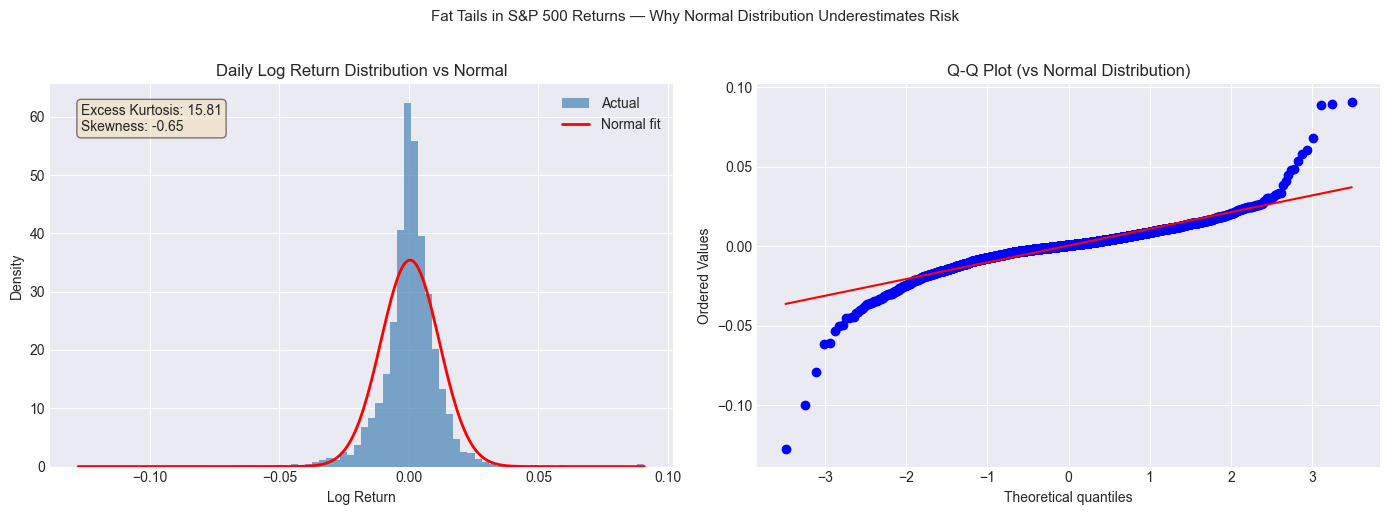

Interpretation: Positive excess kurtosis (leptokurtosis) confirms fat tails — extreme returns occur more frequently than a normal distribution predicts. This is critical for VaR estimation.


In [ ]:
# ── 5.2 Return Distribution Analysis ─────────────────────────────────────────
daily_ret = returns['SP500_log'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with normal overlay
ax = axes[0]
ax.hist(daily_ret, bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='none', label='Actual')
x_range = np.linspace(daily_ret.min(), daily_ret.max(), 300)
normal_pdf = stats.norm.pdf(x_range, daily_ret.mean(), daily_ret.std())
ax.plot(x_range, normal_pdf, 'r-', lw=2, label='Normal fit')
ax.set_title('Daily Log Return Distribution vs Normal', fontsize=12)
ax.set_xlabel('Log Return')
ax.set_ylabel('Density')
ax.legend()

# Annotation: fat tails
kurt = daily_ret.kurtosis()
skew = daily_ret.skew()
ax.text(0.05, 0.95, f'Excess Kurtosis: {kurt:.2f}\nSkewness: {skew:.2f}',
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# QQ Plot
ax2 = axes[1]
stats.probplot(daily_ret, dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot (vs Normal Distribution)', fontsize=12)

plt.suptitle('Fat Tails in S&P 500 Returns — Why Normal Distribution Underestimates Risk', 
             fontsize=11, y=1.02)
plt.tight_layout()

# Safe save with error handling
try:
    os.makedirs('../outputs', exist_ok=True)
    plt.savefig('../outputs/return_distribution.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: return_distribution.png")
except Exception as e:
    print(f"⚠️  Could not save figure: {e}")

plt.show()
print("Interpretation: Positive excess kurtosis (leptokurtosis) confirms fat tails — extreme returns occur more frequently than a normal distribution predicts. This is critical for VaR estimation.")


In [ ]:
# ── 5.3 Rolling Volatility Regimes ───────────────────────────────────────────
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=returns.index, y=returns['vol_21d'] * 100,
    name='21-Day Realised Vol', line=dict(color='#FFC107', width=1)
))
fig.add_trace(go.Scatter(
    x=returns.index, y=returns['vol_63d'] * 100,
    name='63-Day Realised Vol', line=dict(color='#4CAF50', width=2)
))
fig.add_trace(go.Scatter(
    x=master_clean.index, y=master_clean['VIX'],
    name='VIX (Implied Vol)', line=dict(color='#F44336', width=1.5, dash='dot')
))

# Annotate key events
events = {
    '2018-12-24': 'Dec 2018 Selloff',
    '2020-03-16': 'COVID-19 Crash',
    '2022-06-16': '2022 Bear Market'
}
for date, label in events.items():
    fig.add_vline(x=date, line_width=1, line_dash='dash', line_color='gray')
    fig.add_annotation(x=date, y=85, text=label, showarrow=False, 
                       textangle=-90, font=dict(size=9, color='gray'))

fig.update_layout(
    title='Volatility Regimes: Realised vs Implied (VIX)',
    yaxis_title='Annualised Volatility (%)',
    height=450, template='plotly_dark',
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

---
## 6. Macro Factor Correlation & OLS Regression

In [ ]:
# ── 6.1 Build Regression Dataset ─────────────────────────────────────────────
# Align returns with macro factors
reg_df = pd.DataFrame({
    'SP500_ret':    returns['SP500_log'],
    'VIX':          master_clean['VIX'],
    'VIX_chg':      master_clean['VIX'].pct_change(),          # VIX change (flow)
    'Treasury_10Y': master_clean['10Y_Treasury_Yield'],
    'Treasury_chg': master_clean['10Y_Treasury_Yield'].diff(), # Yield change (flow)
    'Fed_Rate':      master_clean['Fed_Funds_Rate'],
    'USD_Index':     master_clean['USD_Index'],
    'USD_chg':       master_clean['USD_Index'].pct_change(),   # USD change (flow)
}).dropna()

print(f"Regression dataset: {reg_df.shape}")
print(reg_df.describe().round(4))

Regression dataset: (2838, 8)
       SP500_ret       VIX   VIX_chg  Treasury_10Y  Treasury_chg  Fed_Rate  \
count  2838.0000 2838.0000 2838.0000     2838.0000     2838.0000 2838.0000   
mean      0.0004   18.3881    0.0034        3.2501       -0.0001    2.4947   
std       0.0113    7.0799    0.0864        0.7188        1.0142    1.4035   
min      -0.1277    9.1400   -0.3575        2.0000       -2.4114    0.1012   
25%      -0.0038   13.6225   -0.0435        2.6276       -0.7349    1.2819   
50%       0.0007   16.6350   -0.0071        3.2578        0.0236    2.4655   
75%       0.0058   21.3000    0.0364        3.8596        0.7118    3.6848   
max       0.0909   82.6900    1.1560        4.4993        2.4299    4.9974   

       USD_Index   USD_chg  
count  2838.0000 2838.0000  
mean     99.9417    0.0008  
std       2.8613    0.0407  
min      95.0005   -0.0934  
25%      97.4690   -0.0275  
50%      99.9392   -0.0004  
75%     102.3678    0.0297  
max     104.9967    0.1038  


In [ ]:
# ── 6.2 Correlation Heatmap ───────────────────────────────────────────────────
corr_matrix = reg_df.corr()

fig = px.imshow(
    corr_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Correlation Matrix: S&P 500 Returns vs Macro Factors',
    aspect='auto'
)
fig.update_layout(height=500, template='plotly_dark')
fig.show()

print("\nCorrelation with S&P 500 Daily Return:")
print(corr_matrix['SP500_ret'].drop('SP500_ret').sort_values(ascending=False).to_string())


Correlation with S&P 500 Daily Return:
Treasury_chg    0.0485
USD_Index       0.0329
Fed_Rate        0.0294
USD_chg         0.0187
Treasury_10Y    0.0166
VIX            -0.1734
VIX_chg        -0.7294


In [ ]:
# ── 6.3 OLS Regression: SP500 ~ VIX_chg + Treasury_chg + USD_chg ─────────────
# We use CHANGES (flow) not LEVELS (stock) to avoid spurious regression with non-stationary series

# ADF Test to confirm stationarity of our regressors
print("ADF Stationarity Tests (p < 0.05 = stationary):")
print("-" * 50)
for col in ['SP500_ret', 'VIX_chg', 'Treasury_chg', 'USD_chg']:
    adf_result = adfuller(reg_df[col].dropna())
    status = "✓ STATIONARY" if adf_result[1] < 0.05 else "✗ NON-STATIONARY"
    print(f"  {col:20s} | ADF stat: {adf_result[0]:7.3f} | p-value: {adf_result[1]:.4f} | {status}")

ADF Stationarity Tests (p < 0.05 = stationary):
--------------------------------------------------


  SP500_ret            | ADF stat: -17.096 | p-value: 0.0000 | ✓ STATIONARY
  VIX_chg              | ADF stat: -21.550 | p-value: 0.0000 | ✓ STATIONARY
  Treasury_chg         | ADF stat: -16.820 | p-value: 0.0000 | ✓ STATIONARY
  USD_chg              | ADF stat: -16.771 | p-value: 0.0000 | ✓ STATIONARY


In [ ]:
# OLS Regression
X_vars = ['VIX_chg', 'Treasury_chg', 'USD_chg']
y = reg_df['SP500_ret']
X = sm.add_constant(reg_df[X_vars])

ols_model = sm.OLS(y, X).fit(cov_type='HC3')  # HC3 = heteroscedasticity-robust standard errors

print(ols_model.summary())
print("\n" + "=" * 60)
print("INTERPRETATION:")
print(f"  R-squared:     {ols_model.rsquared:.4f} ({ols_model.rsquared*100:.2f}% of daily return variance explained)")
print(f"  Note: Low R² is EXPECTED for daily equity returns — macro factors")
print(f"  explain direction of risk, not precise daily magnitude.")

                            OLS Regression Results                            
Dep. Variable:              SP500_ret   R-squared:                       0.534
Model:                            OLS   Adj. R-squared:                  0.534
Method:                 Least Squares   F-statistic:                     107.7
Date:                Mon, 20 Apr 2026   Prob (F-statistic):           4.92e-66
Time:                        15:47:23   Log-Likelihood:                 9789.4
No. Observations:                2838   AIC:                        -1.957e+04
Df Residuals:                    2834   BIC:                        -1.955e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0008      0.000      5.373   

In [ ]:
# ── 6.4 Rolling Beta to VIX ───────────────────────────────────────────────────
# Shows how S&P 500's sensitivity to VIX changes changes over time
rolling_beta_vix = pd.Series(index=reg_df.index, dtype=float, name='beta_vix')

window = 63  # quarterly
for i in range(window, len(reg_df)):
    slice_df = reg_df.iloc[i-window:i]
    x_slice  = sm.add_constant(slice_df['VIX_chg'])
    y_slice  = slice_df['SP500_ret']
    try:
        b = sm.OLS(y_slice, x_slice).fit().params['VIX_chg']
        rolling_beta_vix.iloc[i] = b
    except:
        pass

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=rolling_beta_vix.dropna().index,
    y=rolling_beta_vix.dropna(),
    name='63-Day Rolling Beta (S&P500 ~ VIX Change)',
    line=dict(color='#9C27B0', width=1.5)
))
fig.add_hline(y=0, line_dash='dash', line_color='gray')
fig.update_layout(
    title='Rolling Beta of S&P 500 to VIX Changes (63-Day Window)',
    yaxis_title='Beta Coefficient',
    height=400, template='plotly_dark'
)
fig.show()
print("Interpretation: Negative beta confirms the well-known inverse relationship between equity returns and volatility. Magnitude spikes during stress periods.")

Interpretation: Negative beta confirms the well-known inverse relationship between equity returns and volatility. Magnitude spikes during stress periods.


---
## 7. Monte Carlo Simulation (Geometric Brownian Motion)

**Model**: $dS_t = \mu S_t dt + \sigma S_t dW_t$

Discretised: $S_{t+1} = S_t \cdot \exp\left[(\mu - \frac{\sigma^2}{2})\Delta t + \sigma \sqrt{\Delta t} \, Z\right]$, where $Z \sim N(0,1)$

We simulate 10,000 paths over a 252-day (1-year) horizon to estimate the distribution of potential outcomes.

In [ ]:
# ── 7.1 GBM Parameters from Historical Data ───────────────────────────────────
log_ret = returns['SP500_log'].dropna()

# Calibrate to last 252 days (recent regime)
recent_ret = log_ret.iloc[-252:]

mu_daily    = recent_ret.mean()          # Daily drift
sigma_daily = recent_ret.std()           # Daily volatility
S0          = master_clean['SP500'].iloc[-1]  # Current S&P 500 level

print(f"GBM Parameters (calibrated to last 252 trading days):")
print(f"  Current S&P 500 (S0):    {S0:.2f}")
print(f"  Daily drift (μ):          {mu_daily:.6f}  ({mu_daily*252*100:.2f}% annualised)")
print(f"  Daily volatility (σ):     {sigma_daily:.6f}  ({sigma_daily*np.sqrt(252)*100:.2f}% annualised)")

GBM Parameters (calibrated to last 252 trading days):
  Current S&P 500 (S0):    7126.06
  Daily drift (μ):          0.001103  (27.80% annualised)
  Daily volatility (σ):     0.008351  (13.26% annualised)


In [ ]:
# ── 7.2 Simulate 10,000 Paths ─────────────────────────────────────────────────
np.random.seed(42)  # Reproducibility

N_SIMULATIONS = 10_000
T_DAYS        = 252  # 1 year
dt            = 1    # daily step

# GBM vectorised simulation
Z = np.random.standard_normal((T_DAYS, N_SIMULATIONS))  # shape: (252, 10000)
daily_returns_sim = np.exp(
    (mu_daily - 0.5 * sigma_daily**2) * dt + sigma_daily * np.sqrt(dt) * Z
)

# Price paths
price_paths = S0 * np.cumprod(daily_returns_sim, axis=0)  # shape: (252, 10000)
terminal_prices = price_paths[-1, :]  # Final values after 1 year

# Percentile summary
pcts = [5, 10, 25, 50, 75, 90, 95]
print("Monte Carlo Terminal Price Distribution (1-Year Horizon):")
print("-" * 50)
for p in pcts:
    val = np.percentile(terminal_prices, p)
    chg = (val / S0 - 1) * 100
    print(f"  {p:3d}th percentile: {val:8.2f}  ({chg:+.2f}% from current)")

Monte Carlo Terminal Price Distribution (1-Year Horizon):
--------------------------------------------------
    5th percentile:  7500.51  (+5.25% from current)
   10th percentile:  7853.83  (+10.21% from current)
   25th percentile:  8522.97  (+19.60% from current)
   50th percentile:  9323.56  (+30.84% from current)
   75th percentile: 10191.29  (+43.01% from current)
   90th percentile: 11044.90  (+54.99% from current)
   95th percentile: 11574.71  (+62.43% from current)


In [ ]:
# ── 7.3 Visualise Monte Carlo ─────────────────────────────────────────────────
fig = go.Figure()

# Plot 200 sample paths (not all 10,000 for performance)
sample_paths = price_paths[:, :200]
for i in range(200):
    fig.add_trace(go.Scatter(
        y=sample_paths[:, i],
        mode='lines',
        line=dict(width=0.3, color='rgba(100,150,255,0.2)'),
        showlegend=False
    ))

# Percentile bands
day_axis = np.arange(T_DAYS)
for p, color, name in [
    (95, 'rgba(76,175,80,0.8)',   '95th Pct'),
    (75, 'rgba(33,150,243,0.8)',  '75th Pct'),
    (50, 'rgba(255,255,255,1.0)', 'Median'),
    (25, 'rgba(33,150,243,0.8)',  '25th Pct'),
    (5,  'rgba(244,67,54,0.8)',   '5th Pct')
]:
    pct_series = np.percentile(price_paths, p, axis=1)
    fig.add_trace(go.Scatter(
        y=pct_series, name=name,
        line=dict(color=color, width=2)
    ))

fig.add_hline(y=S0, line_dash='dot', line_color='yellow', 
              annotation_text=f'Current: {S0:.0f}', annotation_position='right')

fig.update_layout(
    title=f'Monte Carlo GBM Simulation: {N_SIMULATIONS:,} Paths, 1-Year Horizon (from {S0:.0f})',
    xaxis_title='Trading Days',
    yaxis_title='S&P 500 Level',
    height=500, template='plotly_dark'
)
fig.show()

---
## 8. Risk Metrics: VaR & CVaR

In [ ]:
# ── 8.1 Historical VaR & CVaR ─────────────────────────────────────────────────
# Historical Simulation (non-parametric)
confidence_levels = [0.90, 0.95, 0.99]

print("RISK METRICS SUMMARY (Daily, Historical Simulation)")
print("=" * 55)
print(f"{'Confidence Level':20s} | {'VaR (%)':10s} | {'CVaR / ES (%)':15s}")
print("-" * 55)

var_results  = {}
cvar_results = {}

for cl in confidence_levels:
    var  = np.percentile(log_ret, (1 - cl) * 100)
    cvar = log_ret[log_ret <= var].mean()
    var_results[cl]  = var
    cvar_results[cl] = cvar
    print(f"  {cl*100:.0f}%                  | {var*100:10.4f} | {cvar*100:15.4f}")

print("\nInterpretation:")
print(f"  95% VaR:  On any given day, there is a 5% probability of losing more")
print(f"            than {abs(var_results[0.95]*100):.2f}% of portfolio value.")
print(f"  95% CVaR: When losses exceed the VaR threshold, the average loss is")
print(f"            {abs(cvar_results[0.95]*100):.2f}% (Expected Shortfall).")

RISK METRICS SUMMARY (Daily, Historical Simulation)
Confidence Level     | VaR (%)    | CVaR / ES (%)  
-------------------------------------------------------
  90%                  |    -1.1160 |         -2.0679
  95%                  |    -1.6785 |         -2.7606
  99%                  |    -3.2996 |         -4.7661

Interpretation:
  95% VaR:  On any given day, there is a 5% probability of losing more
            than 1.68% of portfolio value.
  95% CVaR: When losses exceed the VaR threshold, the average loss is
            2.76% (Expected Shortfall).


In [ ]:
# ── 8.2 Rolling 63-Day VaR ────────────────────────────────────────────────────
rolling_var95 = log_ret.rolling(63).apply(
    lambda x: np.percentile(x, 5), raw=True
)

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=('S&P 500 Daily Return', 'Rolling 63-Day VaR (95%)'))

fig.add_trace(go.Scatter(
    x=log_ret.index, y=log_ret * 100,
    name='Daily Return', line=dict(color='#90CAF9', width=0.5)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=rolling_var95.index, y=rolling_var95 * 100,
    name='95% VaR', line=dict(color='#EF5350', width=2)
), row=2, col=1)

fig.update_layout(height=500, template='plotly_dark',
                  title='Daily Returns vs Rolling 95% VaR')
fig.show()

---
## 9. Sector Beta Analysis

In [ ]:
# ── 9.1 Full-Period Beta for Each Sector ─────────────────────────────────────
sp500_ret_series = returns['SP500_log'].dropna()
X_mkt = sm.add_constant(sp500_ret_series)

sector_betas = {}
sector_alphas = {}
sector_r2 = {}

for ticker in SECTOR_TICKERS.keys():
    col = f'{ticker}_log'
    if col in returns.columns:
        y_s = returns[col].dropna()
        # Align index
        common_idx = X_mkt.index.intersection(y_s.index)
        model = sm.OLS(y_s.loc[common_idx], X_mkt.loc[common_idx]).fit()
        sector_betas[ticker]  = model.params['SP500_log']
        sector_alphas[ticker] = model.params['const'] * 252  # annualised
        sector_r2[ticker]     = model.rsquared

beta_df = pd.DataFrame({
    'Sector':     [SECTOR_TICKERS[t] for t in sector_betas.keys()],
    'Beta':       list(sector_betas.values()),
    'Alpha_Ann':  list(sector_alphas.values()),
    'R_squared':  list(sector_r2.values()),
}, index=sector_betas.keys()).sort_values('Beta', ascending=True)

print("Sector Beta vs S&P 500 (Full Sample):")
print(beta_df.to_string())

Sector Beta vs S&P 500 (Full Sample):
                      Sector   Beta  Alpha_Ann  R_squared
XLP         Consumer Staples 0.5639     0.0117     0.4762
XLU                Utilities 0.5903     0.0262     0.3108
XLV              Health Care 0.7440     0.0031     0.6281
XLRE             Real Estate 0.8044    -0.0256     0.4998
XLB                Materials 0.9621    -0.0188     0.6992
XLI              Industrials 0.9747     0.0100     0.7898
XLC   Communication Services 0.9882     0.0010     0.7529
XLE                   Energy 1.0074    -0.0430     0.3748
XLF               Financials 1.0377    -0.0106     0.7183
XLY   Consumer Discretionary 1.0829    -0.0007     0.8068
XLK               Technology 1.2351     0.0542     0.8634


In [ ]:
# ── 9.2 Sector Beta Bar Chart ─────────────────────────────────────────────────
colors = ['#4CAF50' if b < 1 else '#F44336' for b in beta_df['Beta']]

fig = go.Figure()
fig.add_trace(go.Bar(
    x=beta_df['Beta'], y=beta_df['Sector'],
    orientation='h',
    marker_color=colors,
    text=beta_df['Beta'].round(3),
    textposition='outside'
))
fig.add_vline(x=1.0, line_dash='dash', line_color='yellow',
              annotation_text='Market Beta = 1')
fig.update_layout(
    title='Sector Beta vs S&P 500 (Green = Defensive β<1, Red = Aggressive β>1)',
    xaxis_title='Beta',
    height=450, template='plotly_dark'
)
fig.show()

---
## 10. Save All Cleaned Data to CSV

In [ ]:
# ── 10.1 Create output directory & save ───────────────────────────────────────
os.makedirs('../data', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

# Master price + macro data
master_clean.to_csv('../data/master_data.csv')
print(f"✓ Saved: master_data.csv  ({master_clean.shape})")

# Returns & risk metrics
returns.to_csv('../data/returns_data.csv')
print(f"✓ Saved: returns_data.csv ({returns.shape})")

# Regression dataset
reg_df.to_csv('../data/regression_data.csv')
print(f"✓ Saved: regression_data.csv ({reg_df.shape})")

# Sector betas
beta_df.to_csv('../data/sector_betas.csv')
print(f"✓ Saved: sector_betas.csv")

# Monte Carlo results (terminal distribution)
mc_results = pd.DataFrame({'terminal_prices': terminal_prices})
mc_results.to_csv('../data/monte_carlo_results.csv', index=False)
print(f"✓ Saved: monte_carlo_results.csv ({N_SIMULATIONS:,} simulations)")

# OLS regression summary
try:
    with open('../outputs/ols_regression_summary.txt', 'w') as f:
        f.write(str(ols_model.summary()))
    print(f"✓ Saved: ols_regression_summary.txt")
except Exception as e:
    print(f"⚠️  Could not save regression summary: {e}")

print("\n" + "=" * 50)
print("ALL DATA SAVED SUCCESSFULLY")
print("Ready to load in Streamlit app via relative paths.")


✓ Saved: master_data.csv  ((2839, 17))
✓ Saved: returns_data.csv ((2838, 20))
✓ Saved: regression_data.csv ((2838, 8))
✓ Saved: sector_betas.csv
✓ Saved: monte_carlo_results.csv (10,000 simulations)
✓ Saved: ols_regression_summary.txt

ALL DATA SAVED SUCCESSFULLY
Ready to load in Streamlit app via relative paths.


In [ ]:
# ── 10.2 Final Data Manifest ──────────────────────────────────────────────────
print("DATA MANIFEST FOR README")
print("=" * 60)
print(f"Analysis period:    {master_clean.index[0].date()} → {master_clean.index[-1].date()}")
print(f"Trading days:       {len(master_clean):,}")
print(f"Macro factors:      10Y Treasury Yield, Fed Funds Rate, USD Index, CPI")
print(f"Sector ETFs:        {len(SECTOR_TICKERS)} (all 11 GICS sectors)")
print(f"Monte Carlo paths:  {N_SIMULATIONS:,} (GBM, 1-year horizon)")
print(f"Risk metrics:       90/95/99% VaR, CVaR, Rolling Sharpe")
print(f"Regression:         OLS with HC3 robust SE, ADF stationarity verified")

DATA MANIFEST FOR README
Analysis period:    2015-01-02 → 2026-04-17
Trading days:       2,839
Macro factors:      10Y Treasury Yield, Fed Funds Rate, USD Index, CPI
Sector ETFs:        11 (all 11 GICS sectors)
Monte Carlo paths:  10,000 (GBM, 1-year horizon)
Risk metrics:       90/95/99% VaR, CVaR, Rolling Sharpe
Regression:         OLS with HC3 robust SE, ADF stationarity verified
